# Лабораторная работа №3
## Вариант 3.2
#### Выполнили: Аверьянова Мария, Калягин Дмитрий, Кашникова Анна, Климович Анна


## Исходная задача

Рассмотрим задачу минимизации:

$$
\begin{aligned}
\text{minimize} \quad & f(x) = \sum_{i=1}^n x_i \log x_i \\
\text{subject to} \quad & Ax = b
\end{aligned}
$$

где $x \in \mathbb{R}^n$, $A \in \mathbb{R}^{p \times n}$, $b \in \mathbb{R}^p$, $p < n$.



## 1. Исследование на выпуклость

Целевая функция $f(x)$ является суммой функций вида $h(u) = u \log u$. Исследуем выпуклость этой функции на области $x_i > 0$:

$$
h''(u) = \frac{d^2}{du^2}(u \log u) = \frac{d}{du}(1 + \log u) = \frac{1}{u}
$$

Так как $\frac{1}{u} > 0$ для всех $u > 0$, функция $u \log u$ строго выпукла.
Сумма строго выпуклых функций также строго выпукла, поэтому $f(x)$ строго выпукла на области $x_i > 0$.

Ограничения $Ax = b$ задают аффинное множество, которое является выпуклым.

Поэтому исходная задача — выпуклая.



## Формулировка двойственной задачи

Запишем лагранжиан задачи:

$$
L(x, \lambda) = \sum_{i=1}^n x_i \log x_i + \lambda^T(Ax - b)
$$

Для нахождения двойственной функции $q(\lambda) = \inf_x L(x, \lambda)$ приравняем частную производную по каждому $x_i$ к нулю:

$$
\frac{\partial L}{\partial x_i} = \log x_i + 1 + a_i^T \lambda = 0
$$

Отсюда находим оптимальное $x^*$, выраженное через $\lambda$:

$$
\log x_i^*(\lambda) = -1 - a_i^T \lambda \quad \Rightarrow \quad x_i^*(\lambda) = \exp(-1 - a_i^T \lambda)
$$

Подставим $x^*(\lambda)$ обратно в лагранжиан:

$$
\begin{aligned}
q(\lambda) &= L(x^*(\lambda), \lambda) \\
&= \sum_{i=1}^n x_i^* \log x_i^* + \lambda^T A x^* - \lambda^T b \\
&= \sum_{i=1}^n x_i^* (-1 - a_i^T \lambda) + \sum_{i=1}^n x_i^* (a_i^T \lambda) - b^T \lambda \\
&= \sum_{i=1}^n (-x_i^*) - b^T \lambda \\
&= -\sum_{i=1}^n \exp(-1 - a_i^T \lambda) - b^T \lambda
\end{aligned}
$$

Таким образом, двойственная функция имеет вид:

$$
q(\lambda) = -b^T \lambda - \sum_{i=1}^n \exp(-1 - a_i^T \lambda)
$$

Двойственная задача заключается в максимизации этой функции:

$$
\max_{\lambda \in \mathbb{R}^p} \quad q(\lambda)
$$

Или в форме минимизации:

$$
\text{minimize} \quad b^T \lambda + \sum_{i=1}^n \exp(-1 - a_i^T \lambda)
$$

# 2. Генерация тестовых примеров и эталонное решение через CVXPY

In [36]:
import time
import pickle
import matplotlib.pyplot as plt

import numpy as np
import cvxpy as cp
import pandas as pd

from pathlib import Path
from scipy.linalg import svd
from typing import List, Dict



ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ



In [37]:
def entropy_objective(x: np.ndarray) -> float:
    if np.any(x <= 0):
        return np.inf
    return np.sum(x * np.log(x))


def recover_primal_from_dual(nu: np.ndarray, A: np.ndarray) -> np.ndarray:
    return np.exp(-A.T @ nu - 1)


def generate_full_rank_matrix(p: int, n: int, rng):
    while True:
        A = rng.standard_normal((p, n))
        if np.linalg.matrix_rank(A) == p:
            return A


def nullspace_basis(A: np.ndarray, tol=1e-12) -> np.ndarray:
    U, S, Vt = svd(A, full_matrices=True)
    rank = np.sum(S > tol * S[0])
    return Vt[rank:].T

ГЕНЕРАЦИЯ ЗАДАЧИ

In [38]:
def generate_test_problem(n: int, p: int, seed: int):
    rng = np.random.default_rng(seed)

    A = generate_full_rank_matrix(p, n, rng)

    x_feas = 0.5 + np.abs(rng.standard_normal(n))
    b = A @ x_feas

    N = nullspace_basis(A)

    return {
        'A': A,
        'b': b,
        'x_feas': x_feas,
        'N': N,
        'rng': rng
    }

СТАРТОВЫЕ ТОЧКИ


In [39]:
def generate_feasible_starts(x_ref, N, num_starts, rng):
    starts = []
    n_p = N.shape[1]

    if n_p == 0:
        return [x_ref.copy() for _ in range(num_starts)]

    for _ in range(num_starts):
        z = rng.standard_normal(n_p)
        direction = N @ z

        alpha_max = np.inf
        mask = direction < 0
        if np.any(mask):
            alpha_max = np.min(x_ref[mask] / (-direction[mask])) * 0.5

        alpha = alpha_max * (0.2 + 0.6 * rng.random()) if np.isfinite(alpha_max) else 0

        x0 = x_ref + alpha * direction
        x0 = np.maximum(x0, 1e-8)

        starts.append(x0)

    return starts

CVXPY РЕШЕНИЕ

In [40]:

def solve_primal(A, b):
    n = A.shape[1]
    x = cp.Variable(n)

    objective = cp.Minimize(cp.sum(-cp.entr(x)))
    constraints = [A @ x == b, x >= 1e-9]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if x.value is None:
        raise RuntimeError("Primal solve failed")

    x_star = x.value
    f_star = entropy_objective(x_star)

    return x_star, f_star


def solve_dual(A, b):
    p = A.shape[0]
    nu = cp.Variable(p)

    phi_expr = b @ nu + cp.sum(cp.exp(-1 - A.T @ nu))

    prob = cp.Problem(cp.Minimize(phi_expr))
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if nu.value is None:
        raise RuntimeError("Dual solve failed")

    nu_star = nu.value

    # минимум -q
    phi_star = prob.value
    # максимум q
    q_star = -phi_star

    return nu_star, q_star, phi_star

In [41]:
def build_dataset(
    n_values=range(10, 101, 10),
    num_instances=5,
    num_starts=5,
    base_seed=1000,
    save_path=None,
):
    problems: List[Dict] = []
    global_problem_id = 0

    for n in n_values:
        p = n // 2

        print(f"\n=== n = {n}, p = {p} ===")

        for inst_id in range(num_instances):
            seed = base_seed * n + inst_id

            prob = generate_test_problem(n, p, seed)
            A = prob["A"]
            b = prob["b"]
            N = prob["N"]
            rng = prob["rng"]

            # CVXPY reference solutions
            x_star, f_star = solve_primal(A, b)
            nu_star, q_star, phi_star = solve_dual(A, b)

            x_dual = recover_primal_from_dual(nu_star, A)
            gap = abs(f_star - q_star)

            # primal feasible starts
            primal_starts = generate_feasible_starts(
                prob["x_feas"],
                N,
                num_starts,
                rng,
            )

            # dual starts
            dual_starts = [
                rng.standard_normal(p)
                for _ in range(num_starts)
            ]

            problems.append({
                "problem_id": global_problem_id,
                "n": n,
                "p": p,
                "instance_id": inst_id,
                "seed": seed,
                "A": A,
                "b": b,
                "N": N,
                "x_feas": prob["x_feas"],
                "x_star": x_star,
                "f_star": f_star,
                "nu_star": nu_star,
                "q_star": q_star,
                "phi_star": phi_star,
                "x_dual": x_dual,
                "duality_gap": gap,
                "primal_starts": primal_starts,
                "dual_starts": dual_starts,
            })

            print(f"Instance {inst_id}: gap = {gap:.2e}")
            global_problem_id += 1

    if save_path is not None:
        with open(save_path, "wb") as f:
            pickle.dump(problems, f)
        print(f"\nDataset saved to {save_path}")

    return problems

In [42]:
problems = build_dataset(
    n_values=range(10, 101, 10),
    num_instances=5,
    num_starts=5,
    save_path="entropy_problems.pkl",
)


=== n = 10, p = 5 ===
Instance 0: gap = 9.33e-11
Instance 1: gap = 2.07e-12
Instance 2: gap = 1.65e-12
Instance 3: gap = 1.51e-11
Instance 4: gap = 3.48e-12

=== n = 20, p = 10 ===
Instance 0: gap = 3.88e-13
Instance 1: gap = 1.07e-10
Instance 2: gap = 2.42e-11
Instance 3: gap = 1.95e-12
Instance 4: gap = 1.50e-10

=== n = 30, p = 15 ===
Instance 0: gap = 1.21e-11
Instance 1: gap = 7.41e-11
Instance 2: gap = 1.82e-13
Instance 3: gap = 5.85e-12
Instance 4: gap = 1.28e-12

=== n = 40, p = 20 ===
Instance 0: gap = 4.65e-13
Instance 1: gap = 2.24e-11
Instance 2: gap = 4.21e-13
Instance 3: gap = 2.23e-12
Instance 4: gap = 4.93e-11

=== n = 50, p = 25 ===
Instance 0: gap = 7.35e-13
Instance 1: gap = 4.82e-11
Instance 2: gap = 3.91e-12
Instance 3: gap = 2.54e-11
Instance 4: gap = 1.46e-10

=== n = 60, p = 30 ===
Instance 0: gap = 5.77e-12
Instance 1: gap = 2.69e-12
Instance 2: gap = 1.44e-10
Instance 3: gap = 3.02e-12
Instance 4: gap = 8.96e-12

=== n = 70, p = 35 ===
Instance 0: gap = 1.70e

# 3. Для прямой и двойственной задач, каждого $n \in \{10, 20, \ldots, 100\}$, каждого тестового примера и каждой из 5 начальных точек реализуйте следующие методы для точности $\varepsilon = 0.01^2$:

   a) демпфированный метод Ньютона для задачи с линейными ограничениями (Boyd, §10.2, p. 525); сопоставьте результаты для прямой и двойственной задач;
   
   b) комбинированную схему, в которой на начальном этапе применяется градиентный спуск, а затем осуществляется переход к методу Ньютона;
   
   c) методы Broyden и BFGS, использующие следующие формулы обновления аппроксимации обратного гессиана:

   $$H^{\text{new}} = H + \frac{(s - Hy)s^T H}{s^T H y}$$

   для метода Broyden и

   $$H^{\text{new}} = \left(I - \frac{sy^T}{y^T s}\right) H \left(I - \frac{ys^T}{y^T s}\right) + \frac{ss^T}{y^T s}$$

   для метода BFGS, где

   $$s = x^{k+1} - x^k, \qquad y = \nabla f(x^{k+1}) - \nabla f(x^k).$$


---

$^2$Под точностью понимается выполнение неравенства $|f(x^k) - f^*| \le \varepsilon$, где $f^*$ — оптимальное значение функции.

In [43]:
EPS = 1e-4
MAX_ITER = 100

def newton_primal(problem, x0):
    A = problem['A']
    b = problem['b']
    f_star = problem['f_star']

    x = x0.copy()
    history = []

    # Параметры для line search
    alpha = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        grad = np.log(x) + 1
        H = np.diag(1 / x)
        f_val = np.sum(x * np.log(x))
        history.append({
            "iter": k,
            "obj": f_val,
            "error": abs(f_val - f_star)
        })

        # 1. Проверка критерия остановки
        if abs(f_val - f_star) <= EPS:
            return x, history

        # 2. Решение системы KKT
        KKT = np.block([
            [H, A.T],
            [A, np.zeros((A.shape[0], A.shape[0]))]
        ])
        rhs = -np.concatenate([grad, A @ x - b])

        try:
            sol = np.linalg.solve(KKT, rhs)
            dx = sol[:len(x)]
        except np.linalg.LinAlgError:
            print("KKT matrix singular")
            break

        # 3. Демпфирование (Backtracking line search)
        t = 1.0
        while True:
            x_new = x + t * dx
            if np.any(x_new <= 0):
                t *= beta
            else:
                f_new = np.sum(x_new * np.log(x_new))
                if f_new <= f_val + alpha * t * (grad @ dx):
                    break

                t *= beta

            if t < 1e-12:
                print("Line search failed")
                return x, history

        x = x_new

    return x, history

ДВОЙСТВЕННАЯ ЗАДАЧА: NEWTON

In [44]:
def dual_phi(nu, A, b):
    """
    phi(nu) = -q(nu)
    Минимизируемая двойственная функция.
    """
    return b @ nu + np.sum(np.exp(-1 - A.T @ nu))


def dual_phi_grad(nu, A, b):
    """
    Градиент phi(nu).
    """
    exp_term = np.exp(-1 - A.T @ nu)
    return b - A @ exp_term


def dual_phi_hess(nu, A):
    """
    Гессиан phi(nu).
    """
    exp_term = np.exp(-1 - A.T @ nu)
    return A @ np.diag(exp_term) @ A.T


def newton_dual(problem, nu0):
    A = problem['A']
    b = problem['b']
    phi_star = problem['phi_star']

    nu = nu0.copy()
    history = []

    alpha = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        phi_val = dual_phi(nu, A, b)
        grad = dual_phi_grad(nu, A, b)
        H = dual_phi_hess(nu, A)

        error = abs(phi_val - phi_star)

        history.append({
            "iter": k,
            "obj": phi_val,
            "error": error
        })

        if error <= EPS:
            return nu, history

        try:
            dnu = -np.linalg.solve(H, grad)
        except np.linalg.LinAlgError:
            print("Dual Hessian singular")
            break

        t = 1.0
        while True:
            nu_new = nu + t * dnu
            phi_new = dual_phi(nu_new, A, b)

            if phi_new <= phi_val + alpha * t * (grad @ dnu):
                break

            t *= beta
            if t < 1e-12:
                print("Line search failed")
                return nu, history

        nu = nu_new

    return nu, history

In [45]:
def hybrid_method(problem, x0):
    raise NotImplementedError("Hybrid method not implemented")


def broyden_method(problem, x0):
    raise NotImplementedError("Broyden not implemented")


def bfgs_method(problem, x0):
    raise NotImplementedError("BFGS not implemented")

### Гибридный метод

In [46]:
def projected_gradient_direction(A, grad):
    n = A.shape[1]
    p = A.shape[0]

    KKT = np.block([
        [np.eye(n), A.T],
        [A, np.zeros((p, p))]
    ])

    rhs = -np.concatenate([grad, np.zeros(p)])

    sol = np.linalg.solve(KKT, rhs)
    d = sol[:n]

    return d

In [47]:
def hybrid_primal(problem, x0, switch_tol=1e-2):
    A = problem['A']
    b = problem['b']
    f_star = problem['f_star']

    x = x0.copy()
    history = []

    alpha_armijo = 0.01
    beta = 0.5
    mode = "gradient"

    for k in range(MAX_ITER):
        grad = np.log(x) + 1
        H = np.diag(1 / x)
        f_val = np.sum(x * np.log(x))
        error = abs(f_val - f_star)
        history.append({
            "iter": k,
            "obj": f_val,
            "error": error,
            "mode": mode
        })

        if error <= EPS:
            return x, history

        if mode == "gradient":
            try:
                dx = projected_gradient_direction(A, grad)
            except np.linalg.LinAlgError:
                print("Projected gradient KKT singular")
                return x, history

            if np.linalg.norm(dx) <= switch_tol:
                mode = "newton"

        if mode == "newton":
            KKT = np.block([
                [H, A.T],
                [A, np.zeros((A.shape[0], A.shape[0]))]
            ])
            rhs = -np.concatenate([grad, A @ x - b])
            try:
                sol = np.linalg.solve(KKT, rhs)
                dx = sol[:len(x)]
            except np.linalg.LinAlgError:
                print("Newton KKT singular")
                return x, history

        t = 1.0
        while True:
            x_new = x + t * dx
            if np.any(x_new <= 0):
                t *= beta
            else:
                f_new = np.sum(x_new * np.log(x_new))
                if f_new <= f_val + alpha_armijo * t * (grad @ dx):
                    break
                t *= beta

            if t < 1e-12:
                return x, history
        x = x_new

    return x, history

In [48]:
def hybrid_dual(problem, nu0, switch_tol=1e-2):
    A = problem['A']
    b = problem['b']
    phi_star = problem['phi_star']

    nu = nu0.copy()
    history = []

    alpha_armijo = 0.01
    beta = 0.5
    mode = "gradient"

    for k in range(MAX_ITER):
        phi_val = dual_phi(nu, A, b)
        grad = dual_phi_grad(nu, A, b)
        H = dual_phi_hess(nu, A)

        error = abs(phi_val - phi_star)

        history.append({
            "iter": k,
            "obj": phi_val,
            "error": error,
            "mode": mode
        })

        if error <= EPS:
            return nu, history

        if mode == "gradient":
            dnu = -grad

            if np.linalg.norm(grad) <= switch_tol:
                mode = "newton"

        if mode == "newton":
            try:
                dnu = -np.linalg.solve(H, grad)
            except np.linalg.LinAlgError:
                dnu = -grad
                mode = "gradient"

        t = 1.0
        while True:
            nu_new = nu + t * dnu
            phi_new = dual_phi(nu_new, A, b)

            if phi_new <= phi_val + alpha_armijo * t * (grad @ dnu):
                break

            t *= beta

            if t < 1e-12:
                return nu, history

        nu = nu_new

    return nu, history

СРАВНЕНИЕ МЕТОДОВ

In [49]:
def run_experiments(
    problems,
    primal_solver=None,
    dual_solver=None,
    method_name="method",
    save_dir="results",
    verbose=True,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)
    results = []
    for problem in problems:
        problem_id = problem["problem_id"]
        n = problem["n"]
        instance_id = problem["instance_id"]
        num_starts = len(problem["primal_starts"])

        for start_id in range(num_starts):

            row = {
                "method": method_name,
                "problem_id": problem_id,
                "n": n,
                "p": problem["p"],
                "instance_id": instance_id,
                "start_id": start_id,
            }

            # PRIMAL
            if primal_solver is not None:
                x0 = problem["primal_starts"][start_id]

                t0 = time.time()
                x_sol, hist_p = primal_solver(problem, x0)
                time_p = time.time() - t0

                row.update({
                    "primal_iters": hist_p[-1]["iter"],
                    "primal_time": time_p,
                    "primal_final_error": hist_p[-1]["error"],
                    "primal_success": hist_p[-1]["error"] <= EPS,
                    "primal_history": hist_p,
                })

            # DUAL
            if dual_solver is not None:
                nu0 = problem["dual_starts"][start_id]

                t0 = time.time()
                nu_sol, hist_d = dual_solver(problem, nu0)
                time_d = time.time() - t0

                row.update({
                    "dual_iters": hist_d[-1]["iter"],
                    "dual_time": time_d,
                    "dual_final_error": hist_d[-1]["error"],
                    "dual_success": hist_d[-1]["error"] <= EPS,
                    "dual_history": hist_d,
                })

            results.append(row)

            if verbose:
                msg = (
                    f"method={method_name} | "
                    f"n={n} | inst={instance_id} | start={start_id}"
                )

                if primal_solver is not None:
                    msg += (
                        f" | primal it={row['primal_iters']}, "
                        f"time={row['primal_time']:.4f}, "
                        f"err={row['primal_final_error']:.2e}"
                    )

                if dual_solver is not None:
                    msg += (
                        f" | dual it={row['dual_iters']}, "
                        f"time={row['dual_time']:.4f}, "
                        f"err={row['dual_final_error']:.2e}"
                    )

                print(msg)

    # SAVE RESULTS
    pickle_path = save_dir / f"{method_name}_results.pkl"
    with open(pickle_path, "wb") as f:
        pickle.dump(results, f)
    print(f"\nPickle results saved to {pickle_path}")

    return results

In [50]:
newton_results = run_experiments(
    problems=problems,
    primal_solver=newton_primal,
    dual_solver=newton_dual,
    method_name="newton",
    save_dir="results",
)

method=newton | n=10 | inst=0 | start=0 | primal it=4, time=0.0013, err=5.01e-08 | dual it=7, time=0.0005, err=1.25e-07
method=newton | n=10 | inst=0 | start=1 | primal it=4, time=0.0004, err=3.27e-07 | dual it=7, time=0.0004, err=1.32e-07
method=newton | n=10 | inst=0 | start=2 | primal it=4, time=0.0003, err=1.33e-07 | dual it=5, time=0.0005, err=2.21e-09
method=newton | n=10 | inst=0 | start=3 | primal it=4, time=0.0004, err=7.59e-08 | dual it=4, time=0.0003, err=2.27e-06
method=newton | n=10 | inst=0 | start=4 | primal it=4, time=0.0003, err=1.64e-07 | dual it=6, time=0.0004, err=7.65e-05
method=newton | n=10 | inst=1 | start=0 | primal it=3, time=0.0003, err=9.32e-07 | dual it=4, time=0.0002, err=5.75e-05
method=newton | n=10 | inst=1 | start=1 | primal it=3, time=0.0004, err=1.27e-06 | dual it=4, time=0.0003, err=2.21e-07
method=newton | n=10 | inst=1 | start=2 | primal it=3, time=0.0003, err=8.26e-07 | dual it=7, time=0.0004, err=8.20e-09
method=newton | n=10 | inst=1 | start=3 

In [54]:
hybrid_results = run_experiments(
    problems=problems,
    primal_solver=hybrid_primal,
    dual_solver=hybrid_dual,
    method_name="hybrid",
    save_dir="results",
)

method=hybrid | n=10 | inst=0 | start=0 | primal it=14, time=0.0055, err=5.07e-05 | dual it=45, time=0.0069, err=9.06e-05
method=hybrid | n=10 | inst=0 | start=1 | primal it=7, time=0.0010, err=9.21e-06 | dual it=49, time=0.0060, err=6.40e-05
method=hybrid | n=10 | inst=0 | start=2 | primal it=13, time=0.0018, err=9.89e-05 | dual it=72, time=0.0090, err=6.84e-05
method=hybrid | n=10 | inst=0 | start=3 | primal it=13, time=0.0019, err=4.13e-05 | dual it=11, time=0.0014, err=9.85e-05
method=hybrid | n=10 | inst=0 | start=4 | primal it=8, time=0.0011, err=5.01e-05 | dual it=54, time=0.0067, err=9.21e-05
method=hybrid | n=10 | inst=1 | start=0 | primal it=10, time=0.0020, err=2.58e-05 | dual it=31, time=0.0032, err=9.52e-05
method=hybrid | n=10 | inst=1 | start=1 | primal it=9, time=0.0021, err=3.22e-05 | dual it=34, time=0.0045, err=9.01e-05
method=hybrid | n=10 | inst=1 | start=2 | primal it=10, time=0.0020, err=5.84e-05 | dual it=44, time=0.0053, err=7.59e-05
method=hybrid | n=10 | inst

/tmp/ipykernel_97895/3968932643.py:6: RuntimeWarning: overflow encountered in exp
  return b @ nu + np.sum(np.exp(-1 - A.T @ nu))


method=hybrid | n=30 | inst=0 | start=3 | primal it=11, time=0.0017, err=7.57e-05 | dual it=82, time=0.0136, err=9.90e-05
method=hybrid | n=30 | inst=0 | start=4 | primal it=11, time=0.0029, err=7.00e-05 | dual it=99, time=0.0111, err=1.99e-04
method=hybrid | n=30 | inst=1 | start=0 | primal it=13, time=0.0018, err=3.75e-05 | dual it=71, time=0.0102, err=9.78e-05
method=hybrid | n=30 | inst=1 | start=1 | primal it=13, time=0.0037, err=7.80e-05 | dual it=76, time=0.0125, err=8.92e-05
method=hybrid | n=30 | inst=1 | start=2 | primal it=14, time=0.0021, err=5.73e-05 | dual it=85, time=0.0094, err=9.25e-05
method=hybrid | n=30 | inst=1 | start=3 | primal it=14, time=0.0022, err=9.47e-05 | dual it=81, time=0.0125, err=8.98e-05
method=hybrid | n=30 | inst=1 | start=4 | primal it=13, time=0.0018, err=8.06e-05 | dual it=68, time=0.0126, err=8.81e-05
method=hybrid | n=30 | inst=2 | start=0 | primal it=14, time=0.0029, err=5.81e-05 | dual it=43, time=0.0075, err=9.03e-05
method=hybrid | n=30 | i

In [51]:
df = pd.DataFrame(newton_results)

summary = df.groupby("n").agg({
    "primal_iters": "mean",
    "dual_iters": "mean",
    "primal_time": "mean",
    "dual_time": "mean",
    "primal_final_error": "mean",
    "dual_final_error": "mean",
    "primal_success": "mean",
    "dual_success": "mean"
}).reset_index()

summary

,n,primal_iters,dual_iters,primal_time,dual_time,primal_final_error,dual_final_error,primal_success,dual_success
0,10,3.24,4.96,0.000355,0.000356,0.000007,0.000013,1.0,1.0
1,20,3.60,7.68,0.000703,0.000858,0.000014,0.000012,1.0,1.0
2,30,3.60,9.00,0.000562,0.000737,0.000010,0.000012,1.0,1.0
3,40,4.60,10.52,0.000650,0.000887,0.000017,0.000012,1.0,1.0
4,50,4.52,12.24,0.000795,0.001394,0.000019,0.000014,1.0,1.0
5,60,4.48,15.04,0.001197,0.002094,0.000014,0.000020,1.0,1.0
6,70,4.44,15.48,0.001410,0.002572,0.000033,0.000010,1.0,1.0
7,80,4.56,17.44,0.001507,0.002805,0.000020,0.000011,1.0,1.0
8,90,4.72,18.40,0.001620,0.003116,0.000027,0.000006,1.0,1.0
9,100,4.56,20.48,0.002258,0.004825,0.000009,0.000017,1.0,1.0


<Axes: xlabel='n'>

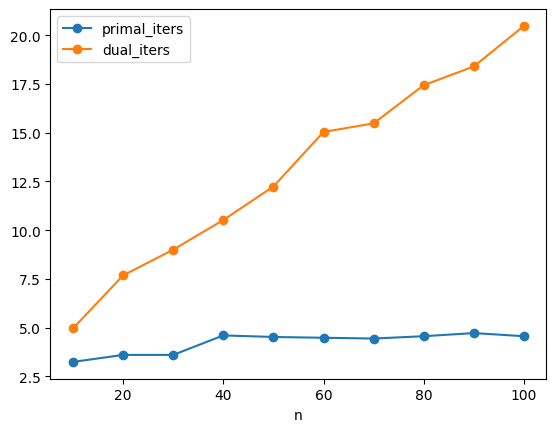

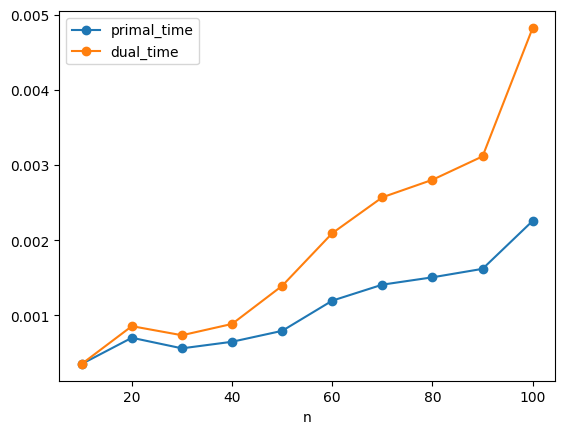

In [52]:
summary.plot(x="n", y=["primal_iters", "dual_iters"], marker="o")
summary.plot(x="n", y=["primal_time", "dual_time"], marker="o")

In [53]:
problem = problems[0]

x0 = problem["primal_starts"][0]
nu0 = problem["dual_starts"][0]

x_sol, hist_p, it_p = newton_primal(problem, x0)
nu_sol, hist_d, it_d = newton_dual(problem, nu0)

plt.semilogy([h["iter"] for h in hist_p], [h["error"] for h in hist_p], label="Primal Newton", marker="o")
plt.semilogy([h["iter"] for h in hist_d], [h["error"] for h in hist_d], label="Dual Newton", marker="o")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

ValueError: not enough values to unpack (expected 3, got 2)